# Multitask RobotEmotions classifiers

This notebook builds the new multimodal evaluation dataset on top of the original RobotEmotions export pipeline, applies the correlation + DTW pose/IMU alignment, and runs the 7 experiment settings.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

cwd = Path.cwd().resolve()
candidate_roots = [cwd, *cwd.parents]
PROJECT_ROOT = next(root for root in candidate_roots if (root / 'pose_module').exists() and (root / 'evaluation').exists())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from evaluation.classifiers import (
    ALL_CAPTURE_BLACKLIST,
    WindowedDatasetConfig,
    build_classifier_capture_table,
    build_windowed_multimodal_dataset,
)

try:
    from evaluation.classifiers import (
        EXPERIMENT_SPECS,
        ModelConfig,
        SplitConfig,
        TrainingConfig,
        run_experiment_suite,
    )
    TORCH_READY = True
    TORCH_IMPORT_ERROR = None
except ImportError as exc:
    TORCH_READY = False
    TORCH_IMPORT_ERROR = exc

pd.set_option('display.max_columns', 40)
pd.set_option('display.width', 260)
PROJECT_ROOT


/home/henriquesouza/IMUGPT/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PosixPath('/home/henriquesouza/IMUGPT')

## Dataset setup

The config below keeps the default 81-frame windows at 20 Hz. `max_windows_per_capture` is intentionally small here so the notebook stays responsive while we iterate; set it to `None` for the full evaluation sweep.

In [2]:
OUTPUT_ROOT = PROJECT_ROOT / 'output' / 'robot_emotions_virtual_imu_v2_all_dataset'
IMU_FEATURE_MODE = 'acc_euler'  # options: 'acc_gyro', 'acc_euler'
DATASET_CONFIG = WindowedDatasetConfig(
    window_size=81,
    overlap=0.5,
    synthetic_variant='raw',
    imu_feature_mode=IMU_FEATURE_MODE,
    selected_sensors=None,
    max_windows_per_capture=None,
    random_state=42,
)

CAPTURES_DF_ALL = build_classifier_capture_table(OUTPUT_ROOT, drop_blacklisted=False)
CAPTURES_DF = build_classifier_capture_table(OUTPUT_ROOT)
display(CAPTURES_DF[['clip_id', 'domain', 'user_id', 'tag_number', 'emotion', 'modality', 'stimulus', 'status']].head())
print({
    'num_captures_total_before_blacklist': len(CAPTURES_DF_ALL),
    'num_blacklisted_capture_specs': len(ALL_CAPTURE_BLACKLIST),
    'num_captures_after_blacklist': len(CAPTURES_DF),
    'domains': sorted(CAPTURES_DF['domain'].unique().tolist()),
})

,clip_id,domain,user_id,tag_number,emotion,modality,stimulus,status
0,robot_emotions_10ms_u02_tag01,10ms,2,1,Neutrality,Standing,None,warning
1,robot_emotions_10ms_u02_tag05,10ms,2,5,Sadness,Sitting,Visual methods,warning
2,robot_emotions_10ms_u02_tag06,10ms,2,6,Sadness,Sitting,Autobiographical recall,warning
3,robot_emotions_10ms_u02_tag07,10ms,2,7,Sadness,Standing,Autobiographical recall,warning
4,robot_emotions_10ms_u02_tag09,10ms,2,9,Happiness,Sitting,Visual methods,warning


{'num_captures_total_before_blacklist': 89, 'num_blacklisted_capture_specs': 9, 'num_captures_after_blacklist': 80, 'domains': ['10ms', '30ms']}


## Dataset build and alignment diagnostics

This cell loads `pose3d.npz`, real `imu.npz`, and synthetic `virtual_imu.npz`, aligns real IMU to the pose timeline with correlation + DTW, and emits synchronized windows for pose, real IMU, and synthetic IMU.

In [3]:
DATASET_BUNDLE = build_windowed_multimodal_dataset(
    OUTPUT_ROOT,
    config=DATASET_CONFIG,
    captures_df=CAPTURES_DF,
)

display(DATASET_BUNDLE['metadata'].head())
display(DATASET_BUNDLE['alignment_summary'].head())
print({
    'num_samples': len(DATASET_BUNDLE['metadata']),
    'pose_shape': DATASET_BUNDLE['pose_windows'].shape,
    'imu_real_shape': DATASET_BUNDLE['imu_real_windows'].shape,
    'imu_synthetic_shape': DATASET_BUNDLE['imu_synthetic_windows'].shape,
    'imu_feature_mode': DATASET_BUNDLE['imu_feature_mode'],
    'selected_sensors': DATASET_BUNDLE['selected_sensors'],
})

,sample_id,capture_id,clip_id,domain,user_id,tag_number,take_id,emotion,modality,stimulus,flat_tag,subject_group,window_index,window_start_index,window_size,window_overlap,quality_status,synthetic_variant,imu_feature_mode,selected_sensors,pose_imu_lag_samples,pose_imu_lag_seconds,pose_imu_correlation_before_dtw,pose_imu_correlation_after_dtw,pose_imu_dtw_normalized_distance,visible_joint_ratio,mean_confidence,temporal_jitter_score,root_drift_score,emotion_id,modality_id,stimulus_id,flat_tag_id
0,robot_emotions_10ms_u02_tag01::window_0000,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,0,0,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
1,robot_emotions_10ms_u02_tag01::window_0001,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,1,40,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
2,robot_emotions_10ms_u02_tag01::window_0002,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,2,80,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
3,robot_emotions_10ms_u02_tag01::window_0003,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,3,120,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9
4,robot_emotions_10ms_u02_tag01::window_0004,robot_emotions_10ms_u02_tag01,robot_emotions_10ms_u02_tag01,10ms,2,1,1,Neutrality,Standing,None,Neutrality|Standing|None,10ms_user_02,4,160,81,0.5,warning,raw,acc_euler,"(waist, head, left_forearm, right_forearm)",-4,-0.133484,0.026847,0.671229,0.178128,0.999972,0.906851,0.000654,0.000231,5,1,1,9


,clip_id,selected_sensors,imu_feature_mode,lag_samples,lag_seconds,correlation_before_dtw,correlation_after_dtw,dtw_normalized_distance,aligned_frequency_hz,num_aligned_frames
0,robot_emotions_10ms_u02_tag01,"[waist, head, left_forearm, right_forearm]",acc_euler,-4,-0.133484,0.026847,0.671229,0.178128,29.966164,2082
1,robot_emotions_10ms_u02_tag05,"[waist, head, left_forearm, right_forearm]",acc_euler,13,0.433823,0.038990,0.567443,0.188057,29.966164,2075
2,robot_emotions_10ms_u02_tag06,"[waist, head, left_forearm, right_forearm]",acc_euler,-15,-0.500565,0.235031,0.712376,0.184795,29.966164,2150
3,robot_emotions_10ms_u02_tag07,"[waist, head, left_forearm, right_forearm]",acc_euler,0,0.000000,0.266520,0.766502,0.161656,29.966164,1938
4,robot_emotions_10ms_u02_tag09,"[waist, head, left_forearm, right_forearm]",acc_euler,9,0.300339,0.116164,0.561349,0.218361,29.966164,2041


{'num_samples': 4075, 'pose_shape': (4075, 81, 22, 16), 'imu_real_shape': (4075, 81, 4, 12), 'imu_synthetic_shape': (4075, 81, 4, 12), 'imu_feature_mode': 'acc_euler', 'selected_sensors': ['waist', 'head', 'left_forearm', 'right_forearm']}


,emotion,modality,stimulus,num_windows
0,Sadness,Sitting,Visual methods,504
1,Neutrality,Standing,None,462
2,Neutrality,Sitting,None,423
3,Happiness,Sitting,Visual methods,400
4,Boredom,Sitting,Visual methods,361
5,Happiness,Sitting,Autobiographical recall,332
6,Curiosity,Standing,Simulation,314
7,Sadness,Sitting,Autobiographical recall,311
8,Boredom,Standing,Visual methods,308
9,Happiness,Standing,Autobiographical recall,246


,lag_samples,correlation_after_dtw,dtw_normalized_distance
count,80.000000,80.000000,80.000000
mean,1.325000,0.615592,0.191772
std,14.024188,0.160407,0.034099
min,-20.000000,0.071088,0.152942
25%,-11.250000,0.555404,0.170511
50%,1.000000,0.646358,0.183319
75%,14.250000,0.729500,0.202906
max,20.000000,0.855669,0.384351


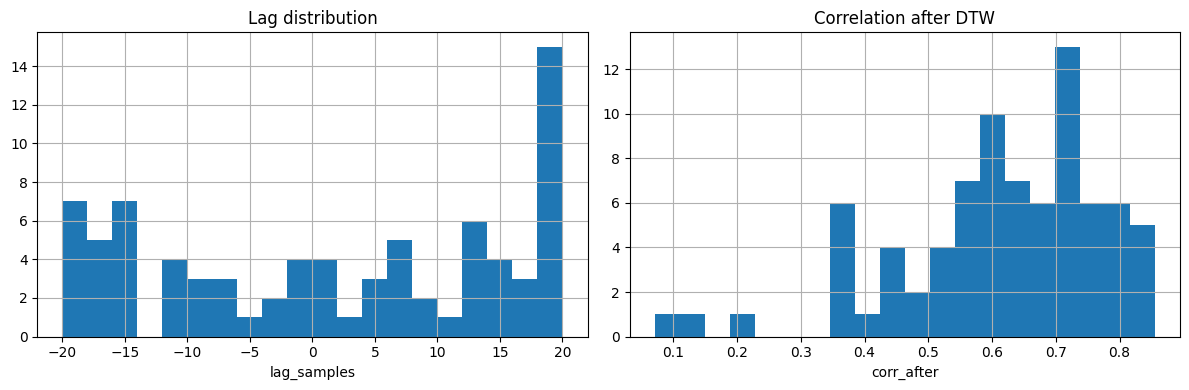

In [4]:
label_distribution = (
    DATASET_BUNDLE['metadata'][['emotion', 'modality', 'stimulus']]
    .value_counts()
    .rename('num_windows')
    .reset_index()
)
display(label_distribution.head(20))

alignment_summary = DATASET_BUNDLE['alignment_summary'][['lag_samples', 'correlation_after_dtw', 'dtw_normalized_distance']]
display(alignment_summary.describe())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
DATASET_BUNDLE['alignment_summary']['lag_samples'].hist(ax=axes[0], bins=20)
axes[0].set_title('Lag distribution')
axes[0].set_xlabel('lag_samples')
DATASET_BUNDLE['alignment_summary']['correlation_after_dtw'].hist(ax=axes[1], bins=20)
axes[1].set_title('Correlation after DTW')
axes[1].set_xlabel('corr_after')
plt.tight_layout()


## Multitask experiment suite

The suite below runs the 7 experiment settings and reports the mean score across subject-group folds.


In [ ]:
if not TORCH_READY:
    display(Markdown(f"**PyTorch is not available in the current `.venv`**: `{TORCH_IMPORT_ERROR}`"))
    SUITE_RESULT = None
else:
    SPLIT_CONFIG = SplitConfig(
        n_splits=5,
        random_state=42,
    )
    MODEL_CONFIG = ModelConfig(
        hidden_dim=128,
        dropout=0.1,
        trunk_blocks=2,
        modality_dropout_p=0.1,
    )
    TRAINING_CONFIG = TrainingConfig(
        batch_size=32,
        max_epochs=10,
        learning_rate=1e-3,
        weight_decay=1e-4,
        device='cuda',
        domain_loss_weight=0.1,
        flat_tag_loss_weight=0.1,
        emotion_loss_weight=1.0,
        modality_loss_weight=1.0,
        stimulus_loss_weight=1.0,
        use_cb_focal=False,
    )
    SUITE_RESULT = run_experiment_suite(
        DATASET_BUNDLE,
        experiment_names=list(EXPERIMENT_SPECS.keys()),
        split_config=SPLIT_CONFIG,
        model_config=MODEL_CONFIG,
        training_config=TRAINING_CONFIG,
    )


Training: 100%|██████████| 10/10 [00:56<00:00,  5.68s/epoch, train_loss=1.0308, val_metric=0.4374]


,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_imu_mixed2r,0.624953,0.581230,0.603521,0.549083,0.450061,0.385767,0.899916,0.524881,0.450061,0.899916,0.524881,emotion: Anger,4075
1,imu_only_mixed2r,0.551460,0.514012,0.532333,0.485322,0.401669,0.344287,0.754893,0.497820,0.401669,0.754893,0.497820,emotion: Anger,4075
2,imu_only_r2r,0.537447,0.498405,0.519291,0.471170,0.381278,0.326810,0.743505,0.487557,0.381278,0.743505,0.487557,emotion: Anger,4075
3,vision_imu_r2r,0.585434,0.534305,0.567295,0.507096,0.380919,0.326502,0.890621,0.484762,0.380919,0.890621,0.484762,emotion: Anger,4075
4,vision_only,0.592010,0.537590,0.574184,0.510852,0.374331,0.320855,0.910907,0.490790,0.374331,0.910907,0.490790,emotion: Anger,4075
5,vision_imu_s2r,0.523983,0.470623,0.509195,0.448441,0.310544,0.266181,0.860833,0.400571,0.310544,0.860833,0.400571,emotion: Anger,4075
6,imu_only_s2r,0.432124,0.388990,0.419763,0.370448,0.259587,0.222504,0.674215,0.362570,0.259587,0.674215,0.362570,emotion: Anger,4075


,metric,value
0,imu_only_gap_s2r,0.105323
1,imu_only_gap_mixed2r,-0.014014
2,imu_only_gain_mixed_over_r2r,0.014014
3,imu_only_gain_mixed_over_s2r,0.119336
4,vision_imu_gap_s2r,0.061451
5,vision_imu_gap_mixed2r,-0.039519
6,vision_imu_gain_mixed_over_r2r,0.039519
7,vision_imu_gain_mixed_over_s2r,0.100970


,experiment_name,split_id,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1,emotion_macro_f1_all,modality_macro_f1,modality_macro_f1_all,stimulus_macro_f1,stimulus_macro_f1_all
0,vision_only,0,0.464138,0.410117,0.452326,0.392399,0.248054,0.212617,0.774656,0.774656,0.369706,0.369706
1,vision_only,1,0.640058,0.587848,0.619524,0.557047,0.431218,0.369615,0.969635,0.969635,0.519321,0.519321
2,vision_only,2,0.612300,0.555469,0.593967,0.527971,0.384979,0.329982,0.902430,0.902430,0.549489,0.549489
3,vision_only,3,0.667593,0.613911,0.646028,0.581563,0.452865,0.388170,0.978447,0.978447,0.571466,0.571466
4,vision_only,4,0.535547,0.472017,0.522146,0.451915,0.281426,0.241222,0.925355,0.925355,0.399860,0.399860
5,imu_only_r2r,0,0.524386,0.492247,0.505537,0.463973,0.395828,0.339281,0.688304,0.688304,0.489027,0.489027
6,imu_only_r2r,1,0.613575,0.562759,0.594037,0.533451,0.410311,0.351695,0.890713,0.890713,0.539702,0.539702
7,imu_only_r2r,2,0.502808,0.458391,0.487325,0.435167,0.325140,0.278691,0.736937,0.736937,0.446348,0.446348
8,imu_only_r2r,3,0.557989,0.513319,0.539926,0.486225,0.379310,0.325123,0.754717,0.754717,0.539939,0.539939
9,imu_only_r2r,4,0.420526,0.392831,0.405776,0.370706,0.309748,0.265498,0.593134,0.593134,0.358695,0.358695


In [7]:
requested_order = [
    'vision_only',
    'imu_only_r2r',
    'imu_only_s2r',
    'imu_only_mixed2r',
    'vision_imu_r2r',
    'vision_imu_s2r',
    'vision_imu_mixed2r',
]
order_map = {name: idx for idx, name in enumerate(requested_order)}

summary_sorted = SUITE_RESULT['summary'].copy()
summary_sorted['experiment_name'] = summary_sorted['experiment_name'].astype(str)
summary_sorted['_sort_key'] = summary_sorted['experiment_name'].map(order_map).fillna(len(requested_order))
summary_sorted = summary_sorted.sort_values('_sort_key', kind='stable').drop(columns=['_sort_key']).reset_index(drop=True)

display(summary_sorted)
display(SUITE_RESULT['domain_gap_summary'])
display(SUITE_RESULT['results_frame'])

,experiment_name,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1_supported_oof,emotion_macro_f1_all_oof,modality_macro_f1_oof,stimulus_macro_f1_oof,emotion_macro_f1,modality_macro_f1,stimulus_macro_f1,unsupported_classes,num_oof_samples
0,vision_only,0.592010,0.537590,0.574184,0.510852,0.374331,0.320855,0.910907,0.490790,0.374331,0.910907,0.490790,emotion: Anger,4075
1,imu_only_r2r,0.537447,0.498405,0.519291,0.471170,0.381278,0.326810,0.743505,0.487557,0.381278,0.743505,0.487557,emotion: Anger,4075
2,imu_only_s2r,0.432124,0.388990,0.419763,0.370448,0.259587,0.222504,0.674215,0.362570,0.259587,0.674215,0.362570,emotion: Anger,4075
3,imu_only_mixed2r,0.551460,0.514012,0.532333,0.485322,0.401669,0.344287,0.754893,0.497820,0.401669,0.754893,0.497820,emotion: Anger,4075
4,vision_imu_r2r,0.585434,0.534305,0.567295,0.507096,0.380919,0.326502,0.890621,0.484762,0.380919,0.890621,0.484762,emotion: Anger,4075
5,vision_imu_s2r,0.523983,0.470623,0.509195,0.448441,0.310544,0.266181,0.860833,0.400571,0.310544,0.860833,0.400571,emotion: Anger,4075
6,vision_imu_mixed2r,0.624953,0.581230,0.603521,0.549083,0.450061,0.385767,0.899916,0.524881,0.450061,0.899916,0.524881,emotion: Anger,4075


,metric,value
0,imu_only_gap_s2r,0.105323
1,imu_only_gap_mixed2r,-0.014014
2,imu_only_gain_mixed_over_r2r,0.014014
3,imu_only_gain_mixed_over_s2r,0.119336
4,vision_imu_gap_s2r,0.061451
5,vision_imu_gap_mixed2r,-0.039519
6,vision_imu_gain_mixed_over_r2r,0.039519
7,vision_imu_gain_mixed_over_s2r,0.100970


,experiment_name,split_id,global_score_macro_f1_mean,global_score_weighted_macro_f1,global_score_macro_f1_mean_all,global_score_weighted_macro_f1_all,emotion_macro_f1,emotion_macro_f1_all,modality_macro_f1,modality_macro_f1_all,stimulus_macro_f1,stimulus_macro_f1_all
0,vision_only,0,0.464138,0.410117,0.452326,0.392399,0.248054,0.212617,0.774656,0.774656,0.369706,0.369706
1,vision_only,1,0.640058,0.587848,0.619524,0.557047,0.431218,0.369615,0.969635,0.969635,0.519321,0.519321
2,vision_only,2,0.612300,0.555469,0.593967,0.527971,0.384979,0.329982,0.902430,0.902430,0.549489,0.549489
3,vision_only,3,0.667593,0.613911,0.646028,0.581563,0.452865,0.388170,0.978447,0.978447,0.571466,0.571466
4,vision_only,4,0.535547,0.472017,0.522146,0.451915,0.281426,0.241222,0.925355,0.925355,0.399860,0.399860
5,imu_only_r2r,0,0.524386,0.492247,0.505537,0.463973,0.395828,0.339281,0.688304,0.688304,0.489027,0.489027
6,imu_only_r2r,1,0.613575,0.562759,0.594037,0.533451,0.410311,0.351695,0.890713,0.890713,0.539702,0.539702
7,imu_only_r2r,2,0.502808,0.458391,0.487325,0.435167,0.325140,0.278691,0.736937,0.736937,0.446348,0.446348
8,imu_only_r2r,3,0.557989,0.513319,0.539926,0.486225,0.379310,0.325123,0.754717,0.754717,0.539939,0.539939
9,imu_only_r2r,4,0.420526,0.392831,0.405776,0.370706,0.309748,0.265498,0.593134,0.593134,0.358695,0.358695


## Optional confusion matrices

When the suite runs, this last block visualizes confusion matrices for the best experiment on its best fold.


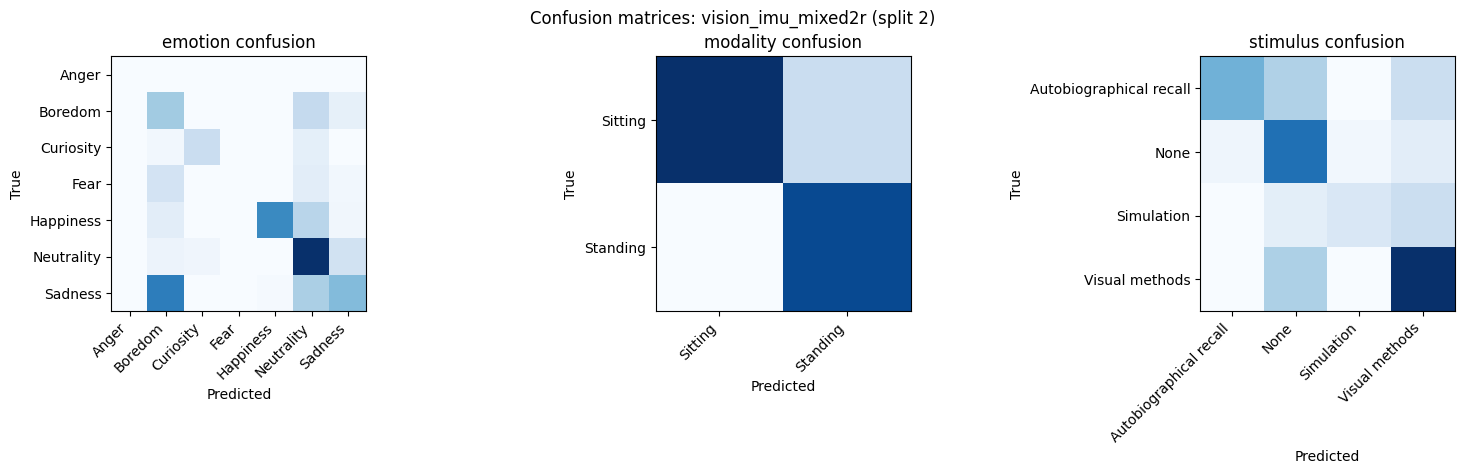

In [6]:
if SUITE_RESULT is not None:
    from evaluation.classifiers.metrics import plot_confusion_matrices

    best_experiment_name = SUITE_RESULT['summary'].iloc[0]['experiment_name']
    best_result = max(
        (
            result for result in SUITE_RESULT['results']
            if result['experiment_name'] == best_experiment_name
        ),
        key=lambda result: float(result['metrics'].get('global_score_macro_f1_mean') or float('-inf')),
    )
    best_split_id = best_result.get('split_id')
    fig, axes = plot_confusion_matrices(best_result['metrics'], DATASET_BUNDLE['label_encoders'])
    split_suffix = '' if best_split_id is None else f' (split {best_split_id})'
    fig.suptitle(f'Confusion matrices: {best_experiment_name}{split_suffix}', y=1.02)
    plt.show()
